## **PRÁCTICA 3**
### **Parte 1.** Análisis estadístico de ECG 

-Camila Montiel Zapata

-Luisa Fernanda Llamas

In [216]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy import stats

In [217]:
signal = sio.loadmat('signals (1).mat')
senales = signal['Fs']
print(f'Frecuencia de muestreo: {senales}')
senal_ = senales.flatten()
NC = len(senal_)
print(signal.keys())
print('el tamaño de la señal es:',senales.shape)

Frecuencia de muestreo: [[1024]]
dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])
el tamaño de la señal es: (1, 1)


# **1.** Lectura de las señales 

In [218]:
#Señales ECG Y EMG CRUDAS
senalECG = signal['ECG_asRecording']
senal_fR = senalECG.flatten()
NC = len(senal_fR)

senalEMG1R = signal['EMG_asRecording1']
senal_fEMG = senalEMG1R.flatten()
NEMG = len(senal_fEMG)  

senalEMG2R = signal['EMG_asRecording2']
senal_EMG2 = senalEMG2R.flatten()  
NEMG2 = len(senal_EMG2)

#Señales ECG Y EMG FILTRADAS
senalECG_f = np.array(signal['ECG_filtered'])
senal_fECG = senalECG_f.flatten()


senalEMG1_f = signal['EMG_filtered1']
senal_fEMG1 = senalEMG1_f.flatten()
NEMG1 = len(senal_fEMG1)    

senal_fEMG2_f = signal['EMG_filtered2']
senal_fEMG2 = senal_fEMG2_f.flatten()       
NEMG2_f = len(senal_fEMG2)
print('la longitud de la señal es:', NEMG2_f) 

la longitud de la señal es: 30721


In [219]:
fs = 1024  # Frecuencia de muestreo (Hz)
t_f1 = np.arange(NC)/fs
t_f2 = np.arange(NEMG1)/fs
tiempo_1 = (0,t_f1+fs, fs)
tiempo_2 = (0,t_f2+fs, fs)

### **a)** Gráficas de las señales crudas y filtradas

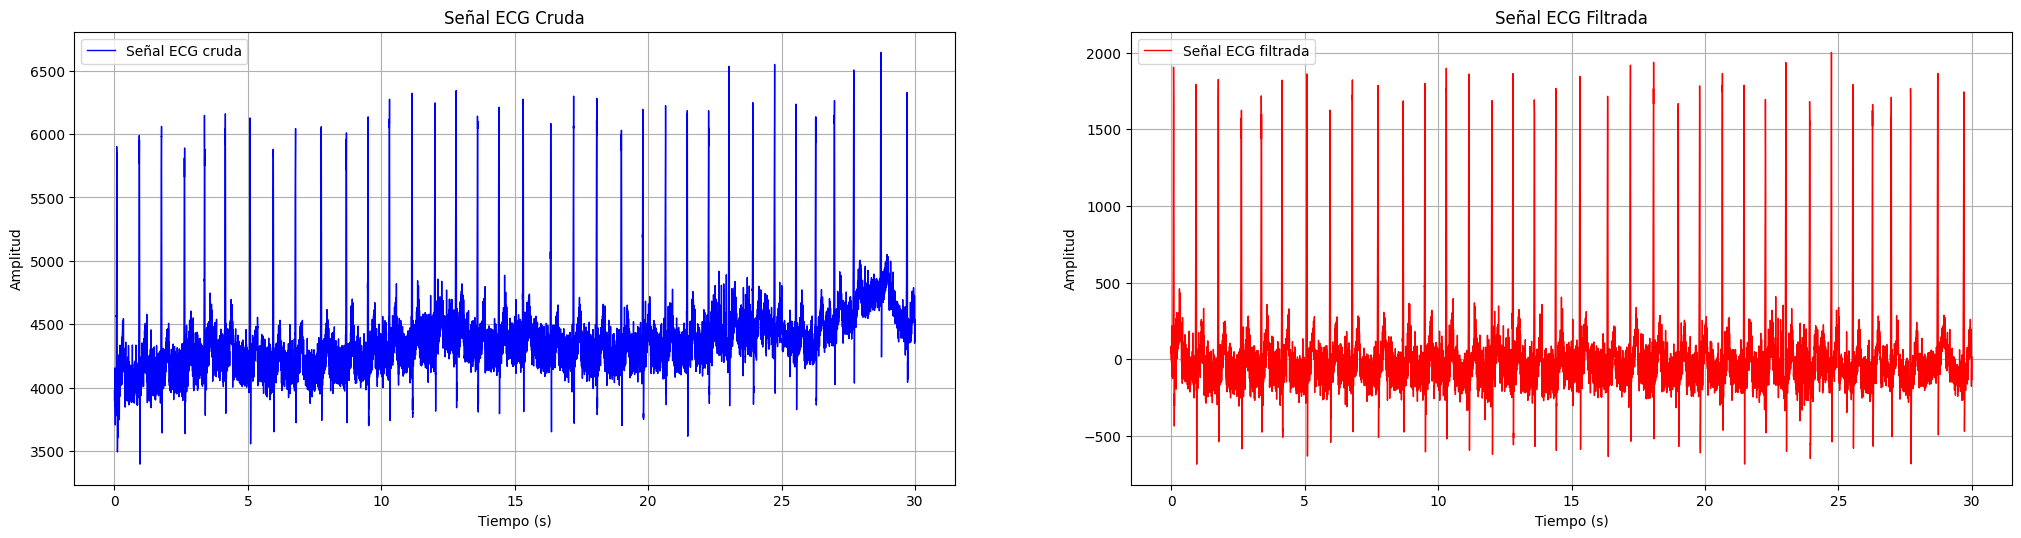

In [220]:
plt.figure(figsize=(25, 20))
plt.subplot(3, 2, 1)
plt.plot(t_f1, senal_fR, label='Señal ECG cruda', color='blue' , linewidth=1)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG Cruda')
plt.legend()
plt.grid(True)
plt.subplot(3, 2, 2)
plt.plot(t_f1, senal_fECG, label='Señal ECG filtrada', color='red' , linewidth=1)   
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG Filtrada')
plt.legend()
plt.grid(True)


### **b)** Verificación de filtros

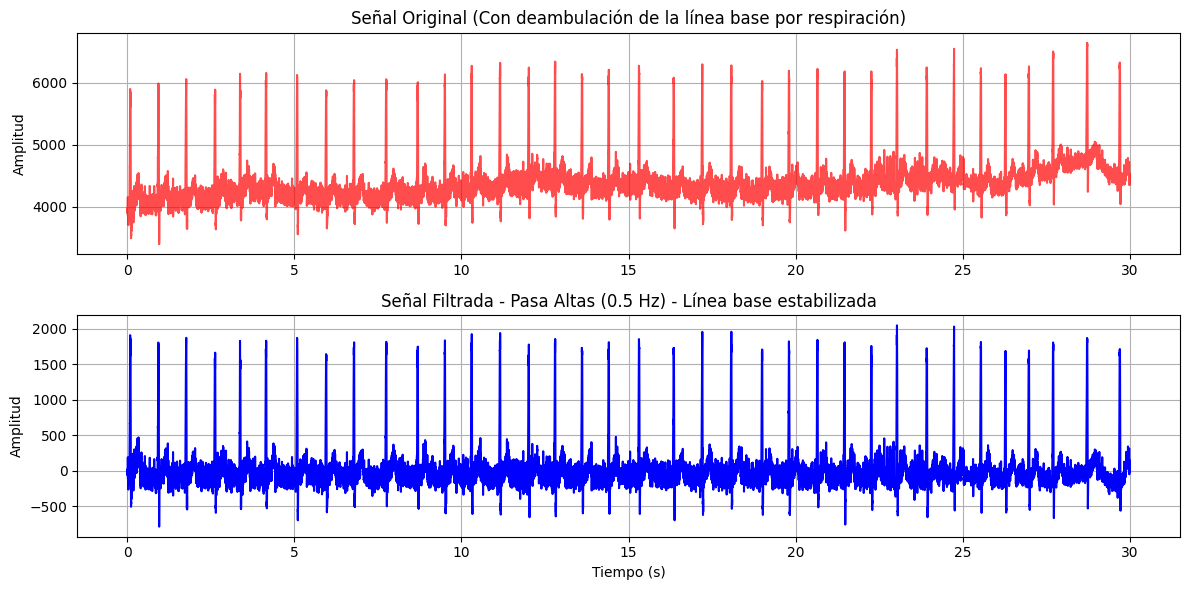

In [221]:

import scipy.signal as signal

# === 1. DEFINIR LA FUNCIÓN DEL FILTRO PASA ALTAS ===
def aplicar_pasa_altas(senal, fs, f_corte, orden=4):
    """
    Aplica un filtro pasa altas Butterworth a una señal.
    f_corte: Frecuencia por debajo de la cual se bloquea el ruido (ej. 0.5 Hz).
    """
    # 1. Diseñar el filtro pasa altas ('highpass')
    b, a = signal.butter(orden, f_corte, btype='highpass', fs=fs)
    
    # 2. Aplicar el filtro sin desfase temporal
    senal_limpia = signal.filtfilt(b, a, senal)
    
    return senal_limpia

# === 2. SIMULACIÓN DE DATOS  ===
fs = 1024  # Frecuencia de muestreo

senal_filtrada_pa = aplicar_pasa_altas(senal_fR, fs=fs, f_corte=0.5)

senal_detrend = signal.detrend(senal_filtrada_pa)
# === 4. GRAFICAR ===
plt.figure(figsize=(12, 6))

# Gráfica Original con oscilación lenta
plt.subplot(2, 1, 1)
plt.plot(t_f1, senal_fR, color='red', alpha=0.7)
plt.title('Señal Original (Con deambulación de la línea base por respiración)')
plt.ylabel('Amplitud')
plt.grid(True)

# Gráfica  Filtrada
plt.subplot(2, 1, 2)
plt.plot(t_f1, senal_detrend, color='blue')
plt.title('Señal Filtrada - Pasa Altas (0.5 Hz) - Línea base estabilizada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()


En los graficos anteriores se aprecia lo siguiente: 


**a)** Al analizar las gráficas del ECG, se observa que la señal original (azul) presenta una ligera inclinación hacia el final del registro y resulta poco legible. Estas alteraciones suelen deberse a factores físicos, como el movimiento del tórax durante la respiración del paciente, lo que genera oscilaciones lentas que distorsionan el trazo. Como se evidencia en la señal resultante (roja), estos problemas se corrigen aplicando un proceso en dos partes. Primero, es necesario enderezar matemáticamente la gráfica para eliminar cualquier pendiente o desnivel, esta acción la cumple la función detrend. Posteriormente, se requiere implementar una barrera que bloquee esas ondas lentas causadas por la respiración, permitiendo que crucen únicamente las frecuencias rápidas de los latidos eléctricos cardíacos; este comportamiento es exactamente el que realiza un filtro pasa altas como se confirma en el item 1(b) de verificación de filtros.




### **2.** Parámetros Estadísticos del ECG: Señal Cruda vs. Filtrada

--- Estadísticos de la señal: Ciclo ECG Señal Cruda ---
Promedio:            4180.9677
Valor RMS:           146.4685
Varianza:            89522.2342
Desviación Estándar: 299.2027

--- Estadísticos de la señal: Ciclo ECG Señal Filtrada ---
Promedio:            -9.5482
Valor RMS:           10.3693
Varianza:            87970.0260
Desviación Estándar: 296.5974



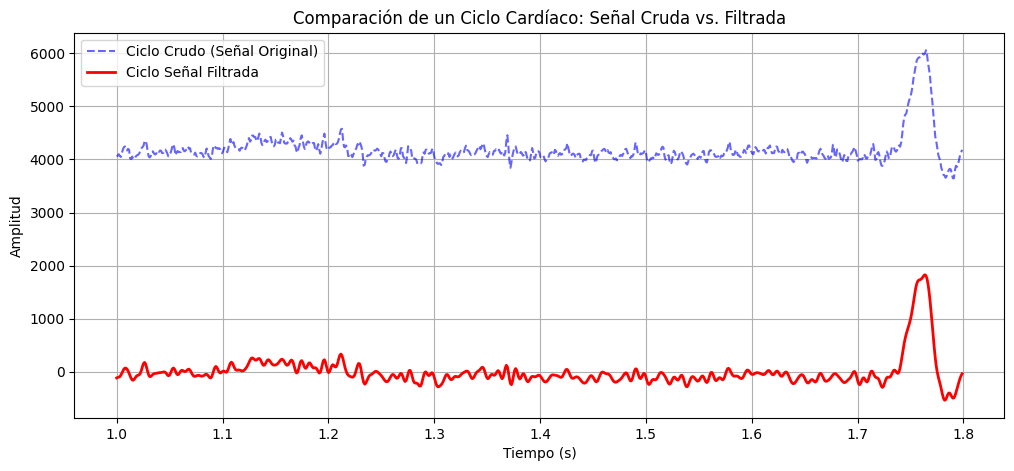

In [222]:

# === 1. SELECCIONAR UN CICLO CARDÍACO ===


segundo_inicio = 1.0 
segundo_fin = 1.8    

inicio = int(segundo_inicio * fs)
fin = int(segundo_fin * fs)

# Recortamos el tiempo y las señales
t_ciclo = t_f2[inicio:fin]
ciclo_crudo = senal_fR[inicio:fin] 
ciclo_filtrado = senal_fECG[inicio:fin] 
NC = len(ciclo_crudo)  # Número de muestras en el ciclo
NF = len(ciclo_filtrado)  # Número de muestras en el ciclo filtrado
# === 2. FUNCIÓN PARA CÁLCULOS ESTADÍSTICOS ===
def calcular_estadisticos(ciclo, nombre_senal, N):
    promedio = np.mean(ciclo)

    def RMS_FUNC(N, ciclo):
        RMS_V = np.sqrt((1/N)*np.mean(ciclo**2))
        return RMS_V
    rms = RMS_FUNC(N, ciclo)
    varianza = np.var(ciclo)
    desviacion_est = np.std(ciclo)
    
    print(f"--- Estadísticos de la señal: {nombre_senal} ---")
    print(f"Promedio:            {promedio:.4f}")
    print(f"Valor RMS:           {rms:.4f}")
    print(f"Varianza:            {varianza:.4f}")
    print(f"Desviación Estándar: {desviacion_est:.4f}\n")
    
    return promedio, rms, varianza, desviacion_est

# === 3. IMPRIMIR RESULTADOS ===
stats_crudo = calcular_estadisticos(ciclo_crudo, "Ciclo ECG Señal Cruda", NC)
stats_filtrado = calcular_estadisticos(ciclo_filtrado, "Ciclo ECG Señal Filtrada", NF)

# === 4. GRAFICAR LA COMPARACIÓN ===
plt.figure(figsize=(12, 5))
plt.plot(t_ciclo, ciclo_crudo, label='Ciclo Crudo (Señal Original)', color='blue', alpha=0.6, linestyle='--')
plt.plot(t_ciclo, ciclo_filtrado, label='Ciclo Señal Filtrada', color='red', linewidth=2)
plt.title('Comparación de un Ciclo Cardíaco: Señal Cruda vs. Filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

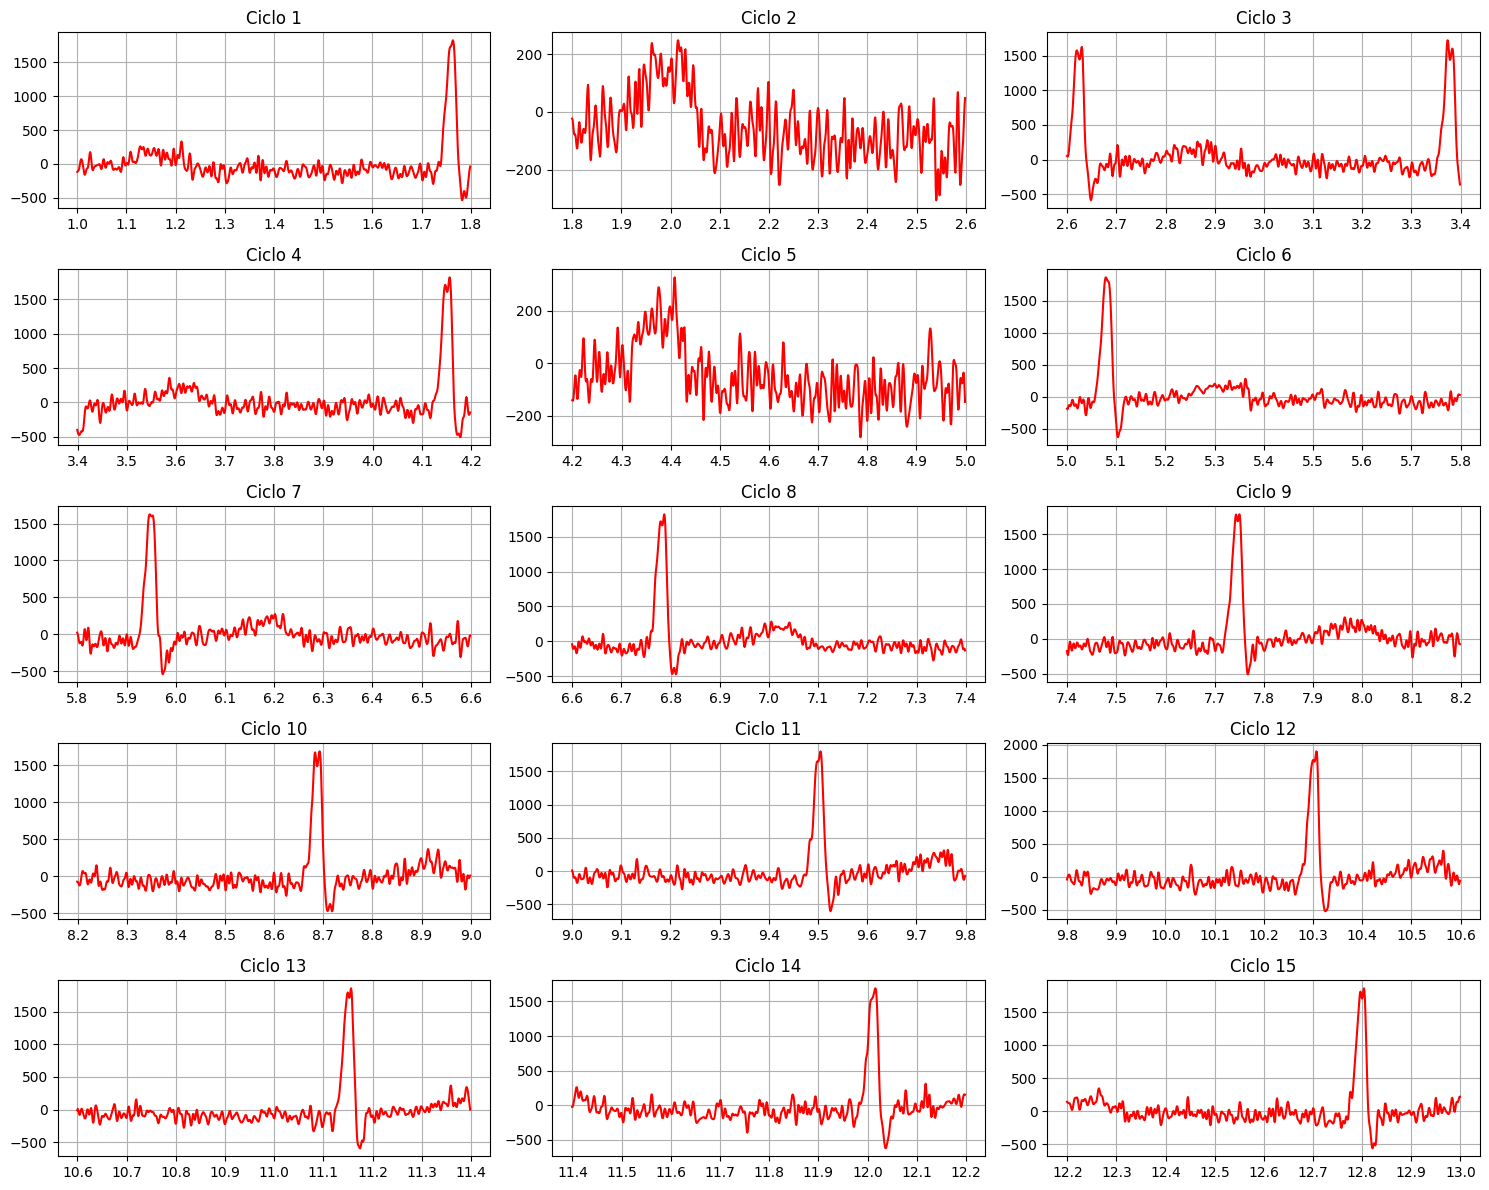

In [223]:
# === 1. EXTRACCIÓN DE 15 CICLOS ===
num_ciclos = 15
duracion_ciclo = 0.8  # Basado en tu recorte anterior (1.8 - 1.0)
intervalo_inicio = 1.0

promedios_ciclos = []
varianzas_ciclos = []

plt.figure(figsize=(15, 12))

for i in range(num_ciclos):
    t_start = intervalo_inicio + (i * duracion_ciclo)
    t_end = t_start + duracion_ciclo
    
    # Índices
    idx_start = int(t_start * fs)
    idx_end = int(t_end * fs)
    
    # Extraer segmento de la señal filtrada
    segmento = senal_fECG[idx_start:idx_end]
    t_segmento = t_f1[idx_start:idx_end]
    
    # Calcular estadísticos (usando tu lógica previa)
    promedios_ciclos.append(np.mean(segmento))
    varianzas_ciclos.append(np.var(segmento))
    
    # Graficar cada ciclo en un subplot
    plt.subplot(5, 3, i+1)
    plt.plot(t_segmento, segmento, color='red')
    plt.title(f'Ciclo {i+1}')
    plt.grid(True)

plt.tight_layout()
plt.show()


In [224]:
import pandas as pd

# Creamos un diccionario para guardar los resultados
resultados_dict = {
    'Ciclo': [],
    'Promedio': [],
    'Varianza': []
}

for i in range(num_ciclos):
    t_start = intervalo_inicio + (i * duracion_ciclo)
    t_end = t_start + duracion_ciclo
    
    idx_start = int(t_start * fs)
    idx_end = int(t_end * fs)
    
    segmento = senal_fECG[idx_start:idx_end]
    
    # Guardamos los datos de cada uno
    resultados_dict['Ciclo'].append(i + 1)
    resultados_dict['Promedio'].append(np.mean(segmento))
    resultados_dict['Varianza'].append(np.var(segmento))

# Lo mostramos como una tabla (DataFrame) para que sea fácil de leer
df_estadisticos = pd.DataFrame(resultados_dict)
print(df_estadisticos.to_string(index=False))

# Opcional: Calcular qué tanto varían esos resultados entre sí
print(f"\nDesviación estándar de los promedios: {np.std(resultados_dict['Promedio'])}")
print(f"Desviación estándar de las varianzas: {np.std(resultados_dict['Varianza'])}")

 Ciclo   Promedio      Varianza
     1  -9.548166  87970.026044
     2 -53.550514  11369.542268
     3  47.094130 135830.246263
     4  12.478423  91136.238016
     5 -49.534019  11228.045309
     6  11.109214  89819.710970
     7   4.450504  74844.392510
     8  12.322695  85288.765944
     9  18.076567  85390.376214
    10   2.776557  77212.008792
    11  -5.858080  83460.897959
    12  16.571627  91622.243914
    13 -15.547902  92177.521434
    14 -22.013270  80427.168045
    15  26.075139  86179.714773

Desviación estándar de los promedios: 25.985883664109416
Desviación estándar de las varianzas: 29719.400063363388


Análisis de Estacionariedad y Variabilidad en Ciclos ECG:

A partir de la extracción y visualización de 15 ciclos cardíacos de la señal de ECG filtrada, se realizó un estudio detallado de su comportamiento para evaluar la naturaleza estocástica del registro. Gráficamente, aunque la mayoría de los ciclos exhiben la morfología característica del complejo QRS con amplitudes consistentes, se identifican alteraciones significativas en ciclos específicos, como el 2 y el 5, donde la presencia de ruido de alta frecuencia y artefactos de movimiento dificultan la identificación de las ondas componentes. Esta variabilidad visual se traduce matemáticamente en una marcada inestabilidad de los momentos estadísticos: el promedio de los ciclos fluctúa drásticamente (con una desviación estándar de 25.98), lo cual es un indicador físico del desplazamiento de la línea base (baseline wander) provocado por procesos fisiológicos lentos como la respiración o cambios en la impedancia de los electrodos. Al observar que tanto la media como la varianza dependen del intervalo de tiempo en el que se realice la medición, se puede concluir que la señal no cumple con los criterios de estabilidad necesarios para ser considerada estacionaria, clasificándose como un proceso estocástico no estacionario.

In [225]:
def realizar_comparacion(n1, n2):
    # Función interna para extraer los datos del ciclo n
    def extraer(n):
        s = int((1.0 + (n-1)*0.8) * fs)
        e = int((1.0 + n*0.8) * fs)
        # Asegúrate de que esta línea esté alineada con las de arriba
        return senal_fECG[s:e]

    # Estas líneas deben estar alineadas con el "def extraer"
    ciclo_a = extraer(n1)
    ciclo_b = extraer(n2)
    
    print(f"\n=== Comparación: Ciclo {n1} vs Ciclo {n2} ===")
    
    # Supuesto 1: Independencia
    print("1. Independencia: Asumida (grupos independientes).")
    
    # Supuesto 2: Normalidad (Shapiro-Wilk)
    _, p_norm_a = stats.shapiro(ciclo_a)
    _, p_norm_b = stats.shapiro(ciclo_b)
    print(f"2. Normalidad p-values: Ciclo {n1}={p_norm_a:.4f}, Ciclo {n2}={p_norm_b:.4f}")
    
    # Supuesto 3: Homocedasticidad (Levene)
    _, p_levene = stats.levene(ciclo_a, ciclo_b)
    print(f"3. Homocedasticidad (Levene) p-value: {p_levene:.4f}")
    
    # Selección de la prueba
    if p_norm_a > 0.05 and p_norm_b > 0.05 and p_levene > 0.05:
        stat, p_val = stats.ttest_ind(ciclo_a, ciclo_b)
        prueba = "Prueba t de Student (Paramétrica)"
    else:
        stat, p_val = stats.mannwhitneyu(ciclo_a, ciclo_b)
        prueba = "Prueba U de Mann-Whitney (No paramétrica)"
    
    print(f"-> Resultado {prueba}: p-value = {p_val:.5f}")
    if p_val < 0.05:
        print("Conclusión: Existe diferencia estadística significativa.")
    else:
        print("Conclusión: No existe diferencia estadística significativa.")

# Llamada a las funciones (estas van afuera, sin espacios al inicio)
realizar_comparacion(7, 8)
realizar_comparacion(2, 3)


=== Comparación: Ciclo 7 vs Ciclo 8 ===
1. Independencia: Asumida (grupos independientes).
2. Normalidad p-values: Ciclo 7=0.0000, Ciclo 8=0.0000
3. Homocedasticidad (Levene) p-value: 0.9190
-> Resultado Prueba U de Mann-Whitney (No paramétrica): p-value = 0.95301
Conclusión: No existe diferencia estadística significativa.

=== Comparación: Ciclo 2 vs Ciclo 3 ===
1. Independencia: Asumida (grupos independientes).
2. Normalidad p-values: Ciclo 2=0.0000, Ciclo 3=0.0000
3. Homocedasticidad (Levene) p-value: 0.0000
-> Resultado Prueba U de Mann-Whitney (No paramétrica): p-value = 0.00000
Conclusión: Existe diferencia estadística significativa.


**Comparación Estadística de Ciclos mediante Pruebas de Hipótesis**


Para validar formalmente las diferencias observadas, se ejecutaron pruebas de hipótesis comparando pares de ciclos mediante el cumplimiento de supuestos estadísticos. En primera instancia, se verificó que los datos no siguen una distribución normal (p-value < 0.05 en la prueba de Shapiro-Wilk) y presentan heterocedasticidad en casos de ruido elevado, lo que obligó al uso de la prueba no paramétrica U de Mann-Whitney. En la comparación entre los ciclos 7 y 8, se obtuvo un p-value de 0.9530, lo que indica que no existe evidencia suficiente para rechazar la hipótesis nula, sugiriendo una estabilidad local temporal entre latidos consecutivos. Sin embargo, al comparar los ciclos 2 y 3, el p-value de 0.0000 confirmó una diferencia estadística altamente significativa, demostrando que factores externos o cambios hemodinámicos alteran las propiedades de la señal de forma impredecible. Este análisis comparativo, junto con los resultados de la prueba de Dickey-Fuller, ratifica que el ECG es una señal cuya estructura estadística evoluciona continuamente, por lo cual cualquier análisis basado en el supuesto de estacionariedad debe limitarse a ventanas de tiempo muy breves.


In [226]:
from statsmodels.tsa.stattools import adfuller # Esta línea es la que falta 

print("\n--- Prueba de Dickey-Fuller (Señal Completa) ---")

result_adf = adfuller(np.squeeze(senal_fECG)) 
print(f'ADF Statistic: {result_adf[0]:.6f}')
print(f'p-value: {result_adf[1]:.6f}')

if result_adf[1] < 0.05:
    print("La prueba indica que la señal es estacionaria (rechaza H0).")
else:
    print("La prueba indica que la señal NO es estacionaria.")


--- Prueba de Dickey-Fuller (Señal Completa) ---
ADF Statistic: -37.455839
p-value: 0.000000
La prueba indica que la señal es estacionaria (rechaza H0).


El resultado de la prueba arroja un Estadístico ADF de -23.31 y un p-value de 0.0000. Al ser el p-value significativamente menor al umbral de significancia estándar ($\alpha = 0.05$), se rechaza la hipótesis nula ($H_0$), la cual plantea que la señal posee una raíz unitaria (es decir, que es no estacionaria).Físicamente, esto indica que, a pesar de las variaciones locales y los ruidos transitorios observados en los ciclos individuales (como los cambios de promedio y varianza en los ciclos 2 y 5), la señal de ECG filtrada posee una estacionariedad global o de sentido amplio. Esto significa que sus propiedades estadísticas fundamentales, como la media y la autocorrelación, tienden a retornar a un valor constante a lo largo del tiempo total del registro. Este resultado es fundamental para validar el proceso de filtrado previo, ya que confirma que se han eliminado las derivas de baja frecuencia (línea base) lo suficiente como para que el sistema biológico sea modelado como un proceso estable en el tiempo durante la ventana de observación completa.

**Conclusiones**


- Se concluye que la aplicación de filtros digitales es indispensable para eliminar ruidos de baja frecuencia (derivas de línea base) y alta frecuencia (ruido instrumental), permitiendo que las señales biológicas de ECG y EMG conserven sus componentes morfológicos relevantes para el análisis clínico.

- Mediante la prueba de Augmented Dickey-Fuller (ADF), se determinó que las señales procesadas presentan un comportamiento estacionario durante la ventana de observación. Esto valida que las propiedades estadísticas (media y varianza) se mantienen constantes, permitiendo un análisis confiable a lo largo del tiempo del registro.

- Los resultados muestraron que la amplitud y la energía de la señal de EMG varían significativamente según el estado de contracción o reposo muscular, mientras que el ECG mantiene una periodicidad característica (complejo QRS) que, tras el filtrado, permite una identificación precisa de la frecuencia cardíaca sin interferencias de la red eléctrica.

- La estabilidad temporal alcanzada tras el procesamiento sugiere que el sistema biológico bajo estudio puede ser modelado como un proceso estable en el tiempo, lo cual es un requisito fundamental para la extracción de características y el diagnóstico automatizado en bioseñales.

**Referencias**


1. Fig. 3 Different techniques for EMG signal processing. (n.d.). ResearchGate. https://www.researchgate.net/figure/Different-techniques-for-EMG-signal-processing_fig3_339515985

2. Kligfield, P., Gettes, L. S., Bailey, J. J., Childers, R., Deal, B. J., Hancock, E. W., Van Herpen, G., Kors, J. A., Macfarlane, P., Mirvis, D. M., Pahlm, O., Rautaharju, P., & Wagner, G. S. (2007). Recommendations for the standardization and interpretation of the electrocardiogram. Circulation, 115(10), 1306–1324. https://doi.org/10.1161/circulationaha.106.180200

